# Classification utilisant KNN et SVC

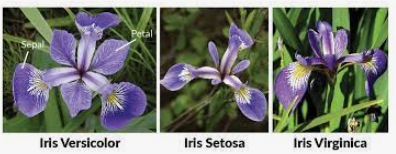


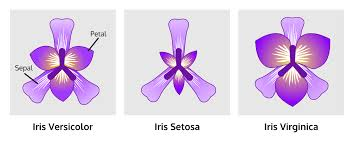

Dans le fichier Iris.csv, la colonne "Species" 0= setosa, 1=versicolor et 2=virginica

0. Importer les librairies nécessaires

In [1]:
import pandas
import matplotlib.pyplot as plt


1. Lire le fichier iris.csv sous forme de tableau de données

In [2]:
iris=pandas.read_csv("iris.csv",sep=";", header=0,decimal=",")
print(iris.shape)
iris.head()


(151, 3)


,petal_length,petal_width,species
0,1.4,0.2,0
1,1.4,0.2,0
2,1.3,0.2,0
3,1.5,0.2,0
4,1.4,0.2,0


2. Analyser les données (info, describe)

In [3]:
iris.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 151 entries, 0 to 150
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   petal_length  151 non-null    float64
 1   petal_width   151 non-null    float64
 2   species       151 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 3.7 KB


In [4]:
iris.describe()

,petal_length,petal_width,species
count,151.000000,151.000000,151.000000
mean,3.779470,1.207285,1.006623
std,1.777013,0.767950,0.820542
min,1.000000,0.100000,0.000000
25%,1.600000,0.300000,0.000000
50%,4.400000,1.300000,1.000000
75%,5.100000,1.800000,2.000000
max,6.900000,2.500000,2.000000


In [5]:
iris['species'].value_counts()

species
2    51
0    50
1    50
Name: count, dtype: int64

Vos remarques sur la base de données:

3. Afficher graphiquement la database

Chaque individu sera représenté avec des petits cercles (marker) de coucleurs différentes (petal_length, petal_width) selon la "species"  g= setosa, r= versicolor et b=virbinica 

In [6]:
petal_length = iris["petal_length"]
petal_width = iris["petal_width"]
lab = iris["species"]

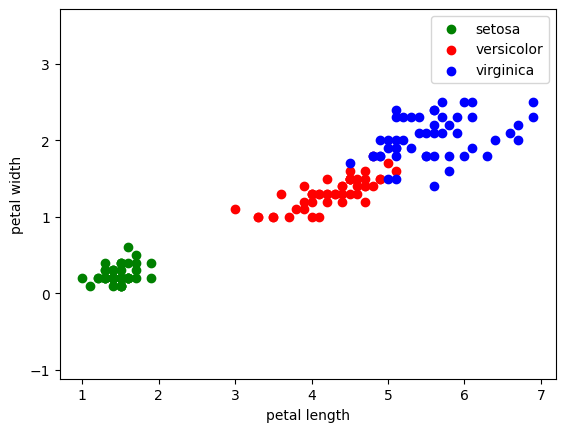

In [7]:
plt.axis('equal')
plt.scatter(petal_length[lab == 0], petal_width[lab == 0], color='g', label='setosa')
plt.scatter(petal_length[lab == 1], petal_width[lab == 1], color='r', label='versicolor')
plt.scatter(petal_length[lab == 2], petal_width[lab == 2], color='b', label='virginica')
plt.xlabel('petal length'); plt.ylabel('petal width')
plt.legend()
plt.show()

4. Placer un pétale avec 2 cm de large et 4,5 cm de long avec la couleur noire (nommé point T)

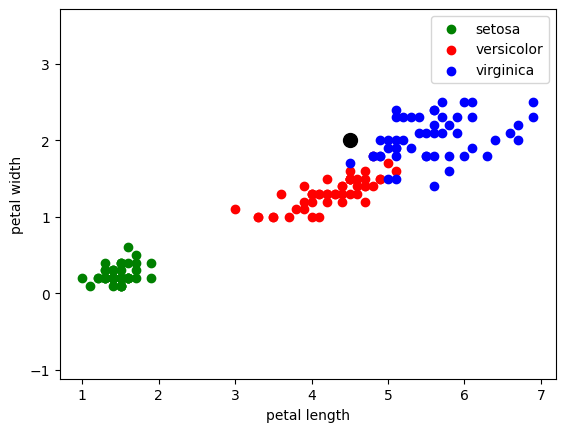

In [8]:
plt.axis('equal')
plt.scatter(petal_length[lab == 0], petal_width[lab == 0], color='g', label='setosa')
plt.scatter(petal_length[lab == 1], petal_width[lab == 1], color='r', label='versicolor')
plt.scatter(petal_length[lab == 2], petal_width[lab == 2], color='b', label='virginica')
# Lab==0 = setosa  lab==1 = versicolor  et Lab==2  = verginica 
plt.xlabel('petal length'); plt.ylabel('petal width')

longueur= 4.5#2.5 #  x, lab
largeur= 2#0.75  # y,lab


plt.scatter(longueur, largeur, color='k',s=100)
plt.legend()

5. Séparation: Entrainement, test

In [9]:
X = iris.drop(columns=['species'])
X.head()

,petal_length,petal_width
0,1.4,0.2
1,1.4,0.2
2,1.3,0.2
3,1.5,0.2
4,1.4,0.2


In [10]:
y = iris["species"]
y.head()

0    0
1    0
2    0
3    0
4    0
Name: species, dtype: int64

In [11]:
# Split the data into training and test sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

6. KNN: entrainement, test, accuracy, matrice de confusion avec k = 3

Prédire la  classe du point T de la question 4

Explication sur KNN: https://www.ibm.com/fr-fr/topics/knn

In [12]:
k=3
#fin valeurs
from sklearn.neighbors import KNeighborsClassifier
#algo knn

model_knn = KNeighborsClassifier(n_neighbors=k)
model_knn.fit(X_train,y_train)

#fin algo knn



KNeighborsClassifier(n_neighbors=3)

In [13]:
#Prédiction des résultats pour train et test 
y_train_pred_knn = model_knn.predict(X_train)  
y_test_pred_knn = model_knn.predict(X_test)  

In [14]:
from sklearn.metrics import accuracy_score
print(accuracy_score(y_train, y_train_pred_knn))

print(accuracy_score(y_test, y_test_pred_knn))

0.975
0.967741935483871


In [15]:
from sklearn.metrics import confusion_matrix

#print(accuracy_score(y_train, y_train_pred_knn))

#print(accuracy_score(y_test, y_test_pred_knn))

confusion_matrix(y_test, y_test_pred_knn)

array([[10,  0,  0],
       [ 0,  8,  1],
       [ 0,  0, 12]])

C:\Users\theodore\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


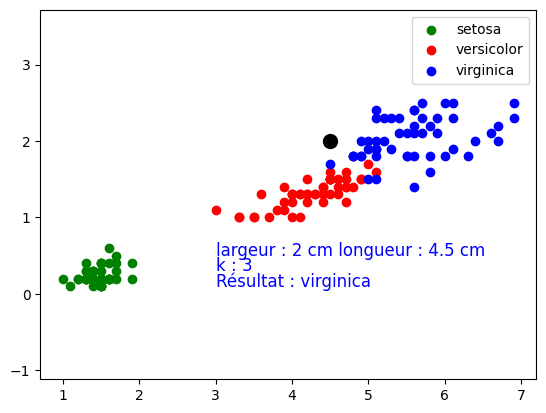

In [16]:
# test

longueur= 4.5#2.5 #  x, lab
largeur= 2#0.75  # y,lab

prediction= model_knn.predict([[longueur,largeur]])

plt.axis('equal')
plt.scatter(petal_length[lab == 0], petal_width[lab == 0], color='g', label='setosa')
plt.scatter(petal_length[lab == 1], petal_width[lab == 1], color='r', label='versicolor')
plt.scatter(petal_length[lab == 2], petal_width[lab == 2], color='b', label='virginica')
# Lab==0 = setosa  lab==1 = versicolor  et Lab==2  = verginica 


plt.scatter(longueur, largeur, color='k',s=100)
plt.legend()



#Affichage résultats
txt="Résultat : "
if prediction[0]==0:
    txt=txt+"setosa"
    color = 'g'
if prediction[0]==1:
    txt=txt+"versicolor"
    color = 'r'
if prediction[0]==2:
    txt=txt+"virginica"
    color = 'b'
plt.text(3,0.5, f"largeur : {largeur} cm longueur : {longueur} cm", color = color, fontsize=12)
plt.text(3,0.3, f"k : {k}",color = color, fontsize=12)
plt.text(3,0.1, txt,color = color, fontsize=12)
#fin affichage résultats

plt.show()

7. Prendre une valeur significativement différente de k et refaire l'expérience.

Donner votre remarque sur les performnances de KNN en fonction de k

In [17]:
k=30
#fin valeurs
from sklearn.neighbors import KNeighborsClassifier
#algo knn

model_knn = KNeighborsClassifier(n_neighbors=k)
model_knn.fit(X_train,y_train)

KNeighborsClassifier(n_neighbors=30)

In [18]:
#Prédiction des résultats pour train et test 
y_train_pred_knn = model_knn.predict(X_train)  
y_test_pred_knn = model_knn.predict(X_test)  

In [19]:
from sklearn.metrics import accuracy_score
print(accuracy_score(y_train, y_train_pred_knn))

print(accuracy_score(y_test, y_test_pred_knn))

0.95
0.9354838709677419


In [20]:
from sklearn.metrics import confusion_matrix

#print(accuracy_score(y_train, y_train_pred_knn))

#print(accuracy_score(y_test, y_test_pred_knn))

confusion_matrix(y_test, y_test_pred_knn)

array([[10,  0,  0],
       [ 0,  9,  0],
       [ 0,  2, 10]])

C:\Users\theodore\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


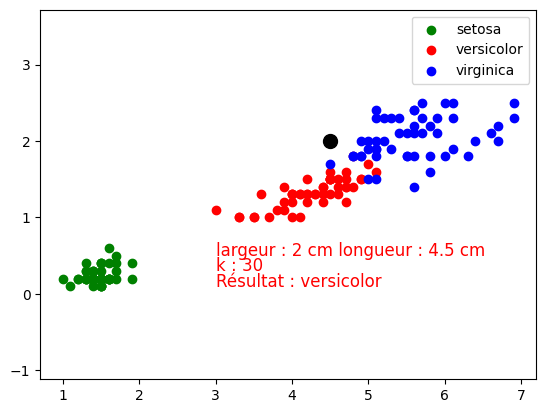

In [21]:
# test

longueur= 4.5#2.5 #  x, lab
largeur= 2#0.75  # y,lab

prediction= model_knn.predict([[longueur,largeur]])

plt.axis('equal')
plt.scatter(petal_length[lab == 0], petal_width[lab == 0], color='g', label='setosa')
plt.scatter(petal_length[lab == 1], petal_width[lab == 1], color='r', label='versicolor')
plt.scatter(petal_length[lab == 2], petal_width[lab == 2], color='b', label='virginica')
# Lab==0 = setosa  lab==1 = versicolor  et Lab==2  = verginica 



plt.scatter(longueur, largeur, color='k',s=100)
plt.legend()



#Affichage résultats
txt="Résultat : "
if prediction[0]==0:
    txt=txt+"setosa"
    color = 'g'
if prediction[0]==1:
    txt=txt+"versicolor"
    color = 'r'
if prediction[0]==2:
    txt=txt+"virginica"
    color = 'b'
plt.text(3,0.5, f"largeur : {largeur} cm longueur : {longueur} cm", fontsize=12, color = color)
plt.text(3,0.3, f"k : {k}", fontsize=12, color = color)
plt.text(3,0.1, txt, fontsize=12, color = color)
#fin affichage résultats

plt.show()

8. Construire un modèle de classification utilisant SVC. Evaluler les performances en comparant avec le modèle KNN

Explication sur SVM:

https://towardsdatascience.com/support-vector-machine-introduction-to-machine-learning-algorithms-934a444fca47

https://blent.ai/blog/a/svm-support-vector-machine

In [22]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

model_svc = SVC(kernel='linear')
model_svc.fit(X_train,y_train)

SVC(kernel='linear')

In [23]:
#Prédiction des résultats pour train et test 
y_train_pred_svc = model_svc.predict(X_train)  
y_test_pred_svc = model_svc.predict(X_test)  

In [24]:
from sklearn.metrics import accuracy_score
print(accuracy_score(y_train, y_train_pred_svc))

print(accuracy_score(y_test, y_test_pred_svc))

0.9666666666666667
0.967741935483871


In [25]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, y_test_pred_knn)

array([[10,  0,  0],
       [ 0,  9,  0],
       [ 0,  2, 10]])

votre remarque: